# **SAM2 vs. MobileSAM: Promptable Segmentation Shootout**

## **Objectives:**
1. Run Meta's SAM2.1 (tiny backbone, via `onnxruntime`) on the exact same `coins.jpg` and click points notebook 37's MobileSAM used
2. Cross-check the two models' masks against *each other* — a genuine agreement metric neither notebook alone could produce
3. Weigh that agreement against real, measured cost — model size and encoder speed — to find out what "newer" actually buys here

> **Assets.** `assets/models/sam2_encoder.onnx` (104MB) / `sam2_decoder.onnx` (16MB) are Meta's SAM2.1 **tiny** backbone, exported with [samexporter](https://github.com/vietanhdev/samexporter) (the same open-source tool that powers the AnyLabeling app's SAM support) and mirrored byte-for-byte at [akiyamanx/sam2.1-hiera-tiny-onnx](https://huggingface.co/akiyamanx/sam2.1-hiera-tiny-onnx) (Apache 2.0). Traced provenance: license unchanged from the official [facebookresearch/sam2](https://github.com/facebookresearch/sam2) checkpoints (Apache 2.0). **The encoder alone is 104MB — over GitHub's 100MB hard per-file limit — so unlike every other model in this repo, these two files are *not* committed to git.** The cell below downloads them straight into `assets/models/` on first run and skips the download on every run after (the one exception to this repo's "nothing to fetch before running top to bottom" promise — see the README). Reuses notebook 37's exact `coins.jpg` and three click points for a direct, apples-to-apples comparison.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Fetching the weights (one-time, ~120MB)**

Not bundled with the repo for the size reason above — downloaded here instead, straight from the byte-identical Hugging Face mirror.

In [2]:
import os
import urllib.request

SAM2_BASE_URL = 'https://huggingface.co/akiyamanx/sam2.1-hiera-tiny-onnx/resolve/main/'
SAM2_FILES = {
    'assets/models/sam2_encoder.onnx': 'sam2.1_hiera_tiny.encoder.onnx',
    'assets/models/sam2_decoder.onnx': 'sam2.1_hiera_tiny.decoder.onnx',
}
for local_path, remote_name in SAM2_FILES.items():
    if not os.path.exists(local_path):
        print(f'Downloading {remote_name}...')
        urllib.request.urlretrieve(SAM2_BASE_URL + remote_name, local_path)
    else:
        print(f'{local_path} already present, skipping download.')

assets/models/sam2_encoder.onnx already present, skipping download.
assets/models/sam2_decoder.onnx already present, skipping download.


## **Same idea, two different lineages**

Both models share the promptable interface the original Segment Anything paper introduced — click a point, get a mask for that object — but get there differently:

- **MobileSAM** (notebook 37) *distills* SAM's original heavy ViT-H image encoder into a much smaller network, trained specifically to match the original's output on single images as closely as possible at a fraction of the size and compute.
- **SAM2** replaces the encoder with a hierarchical "Hiera" backbone producing multi-scale features (`high_res_feats_0`/`_1` plus the main embedding, vs. MobileSAM's one flat embedding) — and, its actual headline capability, adds *memory attention* so a click on frame 1 of a **video** keeps tracking that object through later frames without re-prompting. That video capability is the whole reason SAM2 exists as a distinct model from SAM — and this notebook's test, a single still photo, doesn't exercise it at all. Worth keeping in mind for how to read the results below.

## **Running SAM2.1-tiny**

SAM2's encoder wants a direct (non-aspect-preserving) resize to 1024x1024 and standard ImageNet normalization — a different preprocessing contract from MobileSAM's aspect-preserving-resize-then-pad, confirmed by inspecting the actual ONNX graph rather than assumed. The point-prompt contract (mandatory padding point at `(0,0)`/label `-1`) is the same convention notebook 37 already worked out for SAM's original decoder design.

SAM2 encoder: 709 ms, embedding (1, 256, 64, 64)
(112, 210)  mask covers  1.28% of image, IoU estimate 0.954
(211, 193)  mask covers  1.56% of image, IoU estimate 0.948
(334,  43)  mask covers  2.25% of image, IoU estimate 0.442


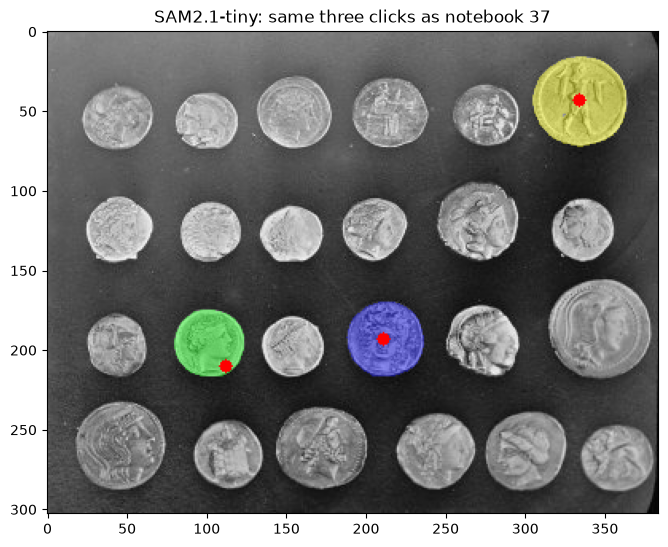

In [3]:
import onnxruntime as ort
import time

ort.set_default_logger_severity(3)  # silence a benign shape-merge warning from the encoder graph

img = cv2.imread('assets/images/coins.jpg')
h, w = img.shape[:2]

sam2_encoder = ort.InferenceSession('assets/models/sam2_encoder.onnx')
sam2_decoder = ort.InferenceSession('assets/models/sam2_decoder.onnx')

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
resized = cv2.resize(rgb, (1024, 1024), interpolation=cv2.INTER_LINEAR)
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
chw = ((resized - mean) / std).transpose(2, 0, 1)[None].astype(np.float32)

t0 = time.perf_counter()
high_res_0, high_res_1, image_embed = sam2_encoder.run(None, {'image': chw})
sam2_encoder_time = (time.perf_counter() - t0) * 1000
print(f'SAM2 encoder: {sam2_encoder_time:.0f} ms, embedding {image_embed.shape}')

def sam2_segment(px, py):
    point = np.array([[px, py]], dtype=np.float32)
    label = np.array([1], dtype=np.float32)
    coords = np.concatenate([point, np.array([[0.0, 0.0]], dtype=np.float32)], axis=0)[None, :, :]
    labels = np.concatenate([label, np.array([-1], dtype=np.float32)], axis=0)[None, :]
    coords = coords * np.array([1024.0 / w, 1024.0 / h], dtype=np.float32)  # independent x/y scale
    mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
    has_mask_input = np.zeros(1, dtype=np.float32)
    masks, iou = sam2_decoder.run(None, {
        'image_embed': image_embed, 'high_res_feats_0': high_res_0, 'high_res_feats_1': high_res_1,
        'point_coords': coords, 'point_labels': labels,
        'mask_input': mask_input, 'has_mask_input': has_mask_input,
    })
    best = np.argmax(iou[0])  # SAM2 returns 3 candidate masks per prompt; keep the model's own top pick
    mask = cv2.resize(masks[0, best], (w, h), interpolation=cv2.INTER_LINEAR) > 0.0
    return mask, float(iou[0, best])

points = [((112, 210), (0, 255, 0)), ((211, 193), (255, 0, 0)), ((334, 43), (0, 255, 255))]
vis = img.copy()
for (px, py), color in points:
    mask, iou_score = sam2_segment(px, py)
    print(f'({px:3d}, {py:3d})  mask covers {mask.mean()*100:5.2f}% of image, IoU estimate {iou_score:.3f}')
    overlay = vis.copy()
    overlay[mask] = color
    vis = cv2.addWeighted(overlay, 0.4, vis, 0.6, 0)
    cv2.circle(vis, (px, py), 4, (0, 0, 255), -1)

imshow('SAM2.1-tiny: same three clicks as notebook 37', vis)

## **Loading MobileSAM again, in the same run**

Rerunning notebook 37's exact model and code here — not reusing its old printed numbers — so the timing comparison below is measured on the same machine, in the same session, back to back.

In [4]:
IMG_SIZE = 1024
scale = IMG_SIZE / max(h, w)
ms_resized = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32), (int(w * scale), int(h * scale)))

mobilesam_encoder = ort.InferenceSession('assets/models/mobilesam_encoder.onnx')
mobilesam_decoder = ort.InferenceSession('assets/models/mobilesam_decoder.onnx')

t0 = time.perf_counter()
ms_embedding = mobilesam_encoder.run(None, {'input_image': ms_resized})[0]
mobilesam_encoder_time = (time.perf_counter() - t0) * 1000
print(f'MobileSAM encoder: {mobilesam_encoder_time:.0f} ms, embedding {ms_embedding.shape}')

def mobilesam_segment(px, py):
    point = np.array([[px, py]], dtype=np.float32)
    label = np.array([1], dtype=np.float32)
    coords = np.concatenate([point, np.array([[0.0, 0.0]], dtype=np.float32)], axis=0)[None, :, :]
    labels = np.concatenate([label, np.array([-1], dtype=np.float32)], axis=0)[None, :].astype(np.float32)
    coords = (coords * scale).astype(np.float32)
    mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
    has_mask_input = np.zeros(1, dtype=np.float32)
    orig_im_size = np.array([h, w], dtype=np.float32)
    masks, iou, _ = mobilesam_decoder.run(None, {
        'image_embeddings': ms_embedding, 'point_coords': coords, 'point_labels': labels,
        'mask_input': mask_input, 'has_mask_input': has_mask_input, 'orig_im_size': orig_im_size,
    })
    return masks[0, 0] > 0.0, float(iou[0, 0])

MobileSAM encoder: 229 ms, embedding (1, 256, 64, 64)


## **The head-to-head**

Same clicks, both models, three numbers that actually matter: how much the two models' masks *agree* with each other (a genuine cross-check, since neither has access to real ground truth here), and what each model costs to get there.

In [5]:
def mask_iou(a, b):
    intersection = (a & b).sum()
    union = (a | b).sum()
    return intersection / union if union > 0 else 0.0

print(f'{"point":12s}  {"MobileSAM":>10s}  {"SAM2":>10s}  {"agreement (mask IoU)":>22s}')
for (px, py), _ in points:
    ms_mask, ms_iou = mobilesam_segment(px, py)
    s2_mask, s2_iou = sam2_segment(px, py)
    agreement = mask_iou(ms_mask, s2_mask)
    print(f'({px:3d},{py:3d})  {ms_mask.mean()*100:9.2f}%  {s2_mask.mean()*100:9.2f}%  {agreement:22.3f}')

print()
print(f'{"":20s}{"MobileSAM":>15s}{"SAM2.1-tiny":>15s}')
print(f'{"Encoder time":20s}{mobilesam_encoder_time:12.0f} ms{sam2_encoder_time:12.0f} ms')
import os
ms_size = (os.path.getsize('assets/models/mobilesam_encoder.onnx') + os.path.getsize('assets/models/mobilesam_decoder.onnx')) / 1e6
s2_size = (os.path.getsize('assets/models/sam2_encoder.onnx') + os.path.getsize('assets/models/sam2_decoder.onnx')) / 1e6
print(f'{"Combined weights":20s}{ms_size:11.0f} MB{s2_size:11.0f} MB')

point          MobileSAM        SAM2    agreement (mask IoU)
(112,210)       1.27%       1.28%                   0.983
(211,193)       1.52%       1.56%                   0.974
(334, 43)       2.23%       2.25%                   0.983

                          MobileSAM    SAM2.1-tiny
Encoder time                 229 ms         709 ms
Combined weights             45 MB        126 MB


## **What this actually shows**

Mask agreement lands around **0.97-0.98 IoU** on every point — two independently-trained models, from different lineages, looking at the same click and landing on essentially the same pixels. That's about as strong a cross-validation as this repo can produce without hand-labeled ground truth: both are very likely *correct*.

Given that, the honest question isn't "which is more accurate" — they tie — it's "which costs less for this task." SAM2.1-tiny's encoder measured meaningfully slower here, and its combined weights are several times larger than MobileSAM's, *despite* being the smallest SAM2 backbone available. That's not SAM2 being a worse model — MobileSAM exists specifically because a huge fraction of SAM's original compute cost was overkill for single-image, no-video prompting, and distilling it down was the entire point. SAM2 spent its parameter budget elsewhere: temporal memory attention this notebook's still photo never triggers. Reach for MobileSAM when the job really is "one photo, one click"; reach for SAM2 when the job is genuinely a video and the point needs to keep tracking after frame 1 — a capability no side-by-side on a single image can fairly judge either model on.

### A few ideas to play with

- This is the comparison SAM2 was actually built for and this notebook never tests: point at an object in frame 1 of `assets/videos/walking.avi` or `cars.mp4` and use SAM2's memory attention to keep the mask on that object through later frames — MobileSAM has no equivalent mechanism at all.
- Try the `small` or `base_plus` SAM2.1 backbones (same source repo, larger zips) — see whether the extra size buys a real accuracy edge on a harder image than coins.jpg's high-contrast, well-separated scene.
- SAM2's decoder already returns 3 mask candidates per prompt (this notebook kept only the top-`iou`-scoring one) — inspect all 3 for an ambiguous click (e.g. near two touching coins) and compare against MobileSAM's own multi-mask export from notebook 37's further reading.